In [1]:

import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
import numpy as np

df_21 = pd.read_csv('../../Projektdatensaetze/2021/ergebnissefahrradzaehlungen2021_REFACTORED.csv',
                 sep=';', skiprows=2)
df_21.drop(index=df_21.index[-1],axis=0,inplace=True)
df_21['time'] = pd.to_datetime(df_21['time'], dayfirst=True, format='%d. %m. %Y %H:%M')
df_21.index = df_21['time']
df_21['days'] = df_21['time'].dt.date

#df_21['5.07 BN - Estermannufer'] = (df_21['5.07 BN - Estermannufer'].
#                                    fillna(df_21['5.07 BN - Estermannufer'].rolling(window=9, min_periods=1, center=True).mean()))
df_21['5.07 BN - Estermannufer'] = df_21['5.07 BN - Estermannufer'].ffill().bfill()
#df_21['5.07 BN - Estermannufer'] = df_21['5.07 BN - Estermannufer'].fillna(df_21['5.07 BN - Estermannufer'].interpolate(method='time'))
#df_21['5.07 BN - Estermannufer'] = df_21['5.07 BN - Estermannufer'].fillna(rolling_mean)
#df_21 = df_21.apply(lambda crossings: crossings.fillna(crossings.mean()) if crossings.dtype in ['float64', 'int64'] else crossings)

df_21 = pd.DataFrame(df_21.groupby('days')['5.07 BN - Estermannufer'].sum())
display(df_21.iloc[28:43])

df_2022 = pd.read_csv('../../Projektdatensaetze/2022/FahrradBonn2022_COPY.csv',
                 sep=';', skiprows=1)
df_2022.drop(index=df_2022.index[-1],axis=0,inplace=True)
df_2022['time'] = pd.to_datetime(df_2022['time'], format='%Y-%m-%d %H:%M')
df_2022['days'] = df_2022['time'].dt.date

df_day_bonn = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Bonn'].sum()
df_day_koeln = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Köln'].sum()
df_22_sum = df_day_bonn + df_day_koeln

df_2023 = pd.read_csv('../../Projektdatensaetze/2023/Fahrradzaehlstellen2023_stuendlich_RENAMED.csv',
                 sep=';')
df_2023['time'] = pd.to_datetime(df_2023['time'], format='%d.%m.%Y %H:%M')
df_2023['time'] = df_2023['time'].dt.strftime('%Y-%m-%d %H:%M')
df_2023['time'] = pd.to_datetime(df_2023['time'], format='%Y-%m-%d %H:%M')
df_2023['days'] = df_2023['time'].dt.date
df_day_23 = df_2023.groupby('days')['5.07 BN - Estermannufer'].sum()

,5.07 BN - Estermannufer
days,
2021-01-29,137.0
2021-01-30,24.0
2021-01-31,24.0
2021-02-01,24.0
2021-02-02,24.0
2021-02-03,24.0
2021-02-04,24.0
2021-02-05,24.0
2021-02-06,24.0


In [2]:
df_ = pd.DataFrame()
df_['5.07 BN - Estermannufer']= df_day_bonn + df_day_koeln
df = pd.concat([df_21, df_, df_day_23])

df = pd.DataFrame(df)
df = df.asfreq('d')
display(df)

#df['5.07 BN - Estermannufer'].dtype


,5.07 BN - Estermannufer
days,
2021-01-01,221.0
2021-01-02,407.0
2021-01-03,320.0
2021-01-04,235.0
2021-01-05,270.0
...,...
2023-12-27,0.0
2023-12-28,0.0
2023-12-29,3.0


In [3]:
#prüfe auf Stationarität
from statsmodels.tsa.stattools import adfuller
result = adfuller(df)
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -2.2811
p-value = 0.1781


Datenaufbereitung

1. Vergleiche Autokorrelation vs. partielle Autokorrelation
2. teile in Trainings- und Testdaten ein
3. Stelle Stationarität her

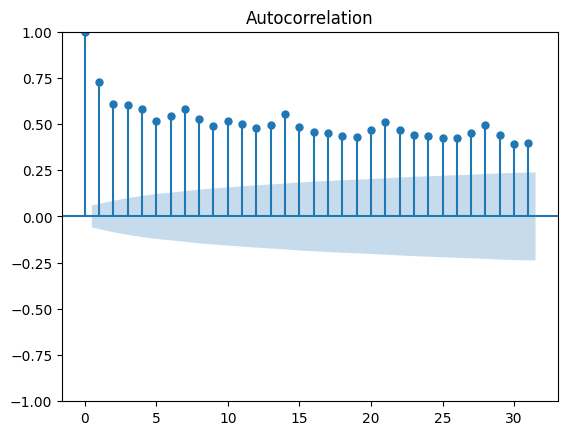

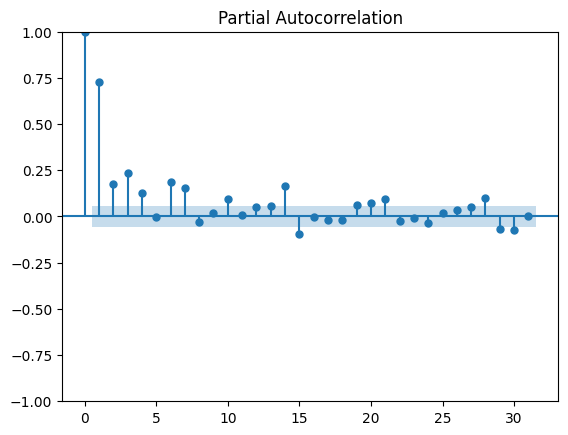

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df)
plot_pacf(df)
plt.show()

In [5]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]
display(df_train)


,5.07 BN - Estermannufer
days,
2021-01-01,221.0
2021-01-02,407.0
2021-01-03,320.0
2021-01-04,235.0
2021-01-05,270.0
...,...
2023-09-09,1385.0
2023-09-10,1861.0
2023-09-11,1180.0


In [6]:
df_train.loc[:,'differences'] = df_train['5.07 BN - Estermannufer'].diff().fillna(0)
result = adfuller(df_train['differences'])
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -11.2624
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\1219441060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train['5.07 BN - Estermannufer'].diff().fillna(0)


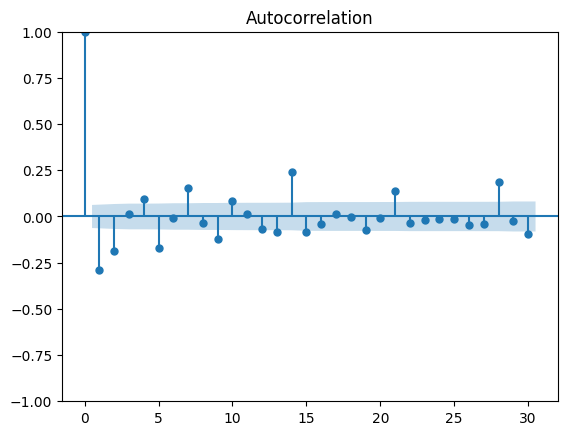

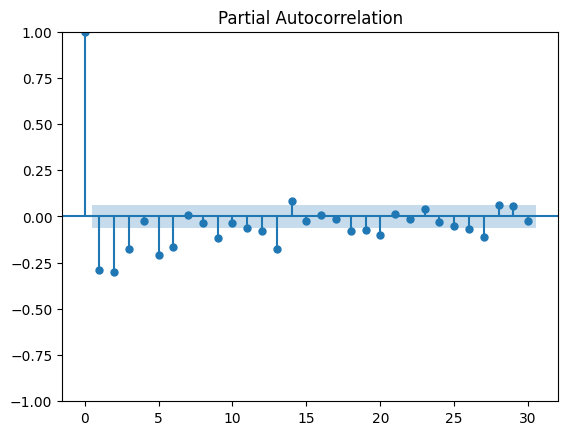

In [7]:
plot_acf(df_train.loc[:,'differences'])
plot_pacf(df_train.loc[:,'differences'])
plt.show()

                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(1, 1, 0)   Log Likelihood               -7182.739
Date:                     Sun, 19 Jan 2025   AIC                          14369.477
Time:                             10:19:15   BIC                          14379.262
Sample:                         01-01-2021   HQIC                         14373.199
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2899      0.019    -15.129      0.000      -0.327      -0.252
sigma2      1.264e+05   3180.340     39.737      0.000     1.2e+05    1.33e+05
Ljung-Box (L

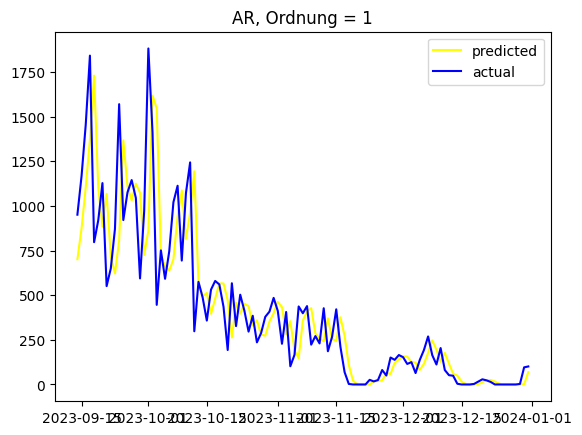

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\3632545333.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.loc[:,'intervals'] = (df_test['5.07 BN - Estermannufer'] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\3632545333.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['group'] = df_test['5.07 BN - Estermannufer'].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\

mean absolute error (mae): ARIMA: 147.7220, simple: 160.7339
mean squared error (mse): ARIMA: 66723.3469, simple: 70775.1743
mean absolute percentage error (mape): ARIMA: 0.5444, simple: 0.5175
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(2, 1, 0)   Log Likelihood               -7136.803
Date:                     Sun, 19 Jan 2025   AIC                          14279.606
Time:                             10:19:16   BIC                          14294.284
Sample:                         01-01-2021   HQIC                         14285.189
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

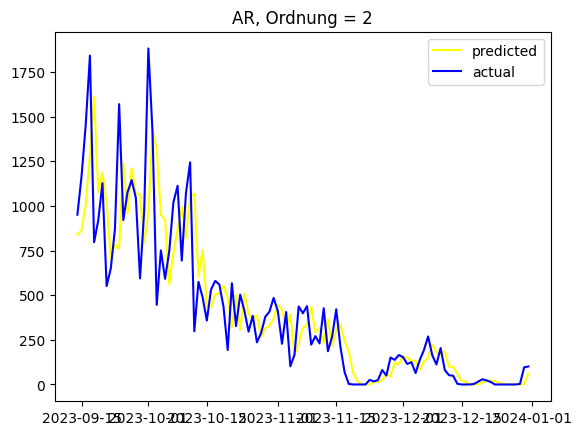

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\3632545333.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['group'] = df_test['5.07 BN - Estermannufer'].apply(lambda x: '≤ 10' if x <= 10 else '> 10')


mean absolute error (mae): ARIMA: 143.2428, simple: 160.7339
mean squared error (mse): ARIMA: 56476.2055, simple: 70775.1743
mean absolute percentage error (mape): ARIMA: 0.5520, simple: 0.5175
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(3, 1, 0)   Log Likelihood               -7120.952
Date:                     Sun, 19 Jan 2025   AIC                          14249.904
Time:                             10:19:17   BIC                          14269.475
Sample:                         01-01-2021   HQIC                         14257.348
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

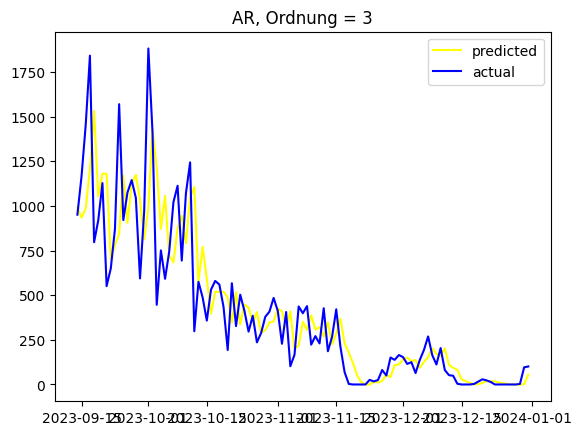

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\3632545333.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['group'] = df_test['5.07 BN - Estermannufer'].apply(lambda x: '≤ 10' if x <= 10 else '> 10')


mean absolute error (mae): ARIMA: 143.2297, simple: 160.7339
mean squared error (mse): ARIMA: 55680.9898, simple: 70775.1743
mean absolute percentage error (mape): ARIMA: 0.5591, simple: 0.5175
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(4, 1, 0)   Log Likelihood               -7120.583
Date:                     Sun, 19 Jan 2025   AIC                          14251.165
Time:                             10:19:20   BIC                          14275.629
Sample:                         01-01-2021   HQIC                         14260.470
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

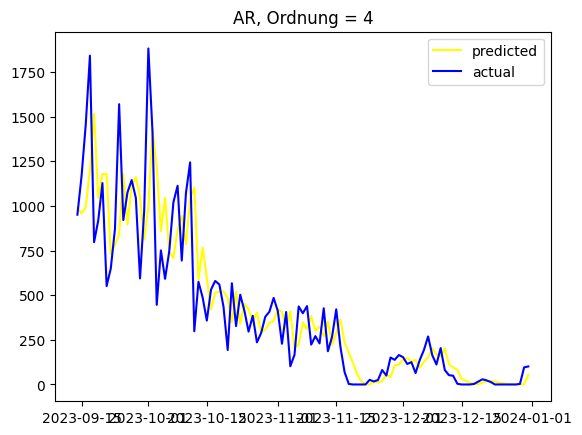

mean absolute error (mae): ARIMA: 142.6027, simple: 160.7339
mean squared error (mse): ARIMA: 55203.8371, simple: 70775.1743
mean absolute percentage error (mape): ARIMA: 0.5588, simple: 0.5175


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_6304\3632545333.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['group'] = df_test['5.07 BN - Estermannufer'].apply(lambda x: '≤ 10' if x <= 10 else '> 10')


In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error


#Log Likelyhood: hoch, AIC: niedrig

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 5):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start='2023-09-14')
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    start_date = '2023-09-14'
    end_date='2023-12-31'
    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc['2023-09-14':'2023-12-31', '5.07 BN - Estermannufer'],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, '5.07 BN - Estermannufer'], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test['5.07 BN - Estermannufer'] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test['group'] = df_test['5.07 BN - Estermannufer'].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc['2023-09-14':'2023-12-31', '5.07 BN - Estermannufer']
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group['5.07 BN - Estermannufer'], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group['5.07 BN - Estermannufer'], group['simple_predict']))
        '''
        if df_test['5.07 BN - Estermannufer'].iloc[y] > 10:
            act = df_test['5.07 BN - Estermannufer'].iloc[y]
            pred_ar = df_test['predicted'].iloc[y]
            pred_simp = df_test['simple_predict'].iloc[y]
            mape_arima_list[0].append(act)
            mape_arima_list[1].append(pred_ar)
            mape_simple_list[0].append(act)
            mape_simple_list[1].append(pred_simp)
            '''
    #display(mape_arima)
    #display(mape_simple)

    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Vergleich mit Moving Averages

                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  986
Model:                    SARIMAX(0, 1, 1)   Log Likelihood               -7125.044
Date:                     Sun, 19 Jan 2025   AIC                          14254.089
Time:                             10:19:23   BIC                          14263.874
Sample:                         01-01-2021   HQIC                         14257.811
                              - 09-13-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.6631      0.016    -41.735      0.000      -0.694      -0.632
sigma2      1.123e+05   2702.058     41.549      0.000    1.07e+05    1.18e+05
Ljung-Box (L

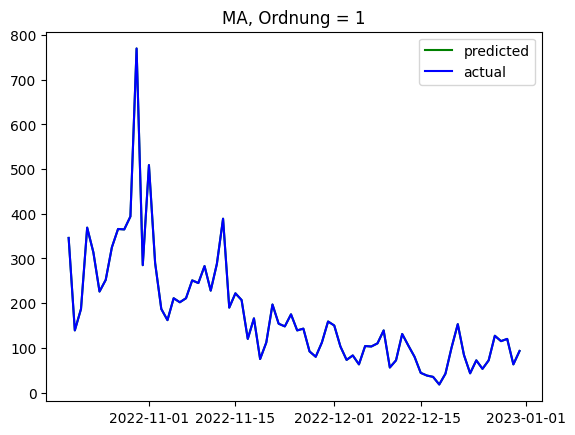

mean absolute error (mae): ARIMA: 74.5794, simple: 160.7339
mean squared error (mse): ARIMA: 10100.9984, simple: 70775.1743


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 2):
    p, d, q = 0, 1, i
    #arima = SARIMAX(df_train['differences'], order=(p, d, q), freq='D')
    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)
    
    # Vorhersage
    predicted = result_new.predict(start='2023-10-20')
    tmp = pd.DataFrame(predicted)
    #tmp['differences'] = tmp['predicted_mean']
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    #display(tmp)
    #display(df_train)
    
    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)
    

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    
    # Plotten
    plt.title('MA, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r['5.07 BN - Estermannufer'].iloc[656: 730], color='green', label='predicted')
    plt.plot(df['5.07 BN - Estermannufer'].iloc[656: 730], color='blue', label='actual')
    plt.legend()
    plt.show()
    
    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()
    
    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    
    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))

Seasonal ARIMA

In [10]:
from sklearn.preprocessing import MinMaxScaler
maximum = max(df['5.07 BN - Estermannufer'])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[['5.07 BN - Estermannufer']]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])


In [11]:
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['5.07 BN - Estermannufer'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,5.07 BN - Estermannufer,differences,scaled,log,days_noyear,day_mean,cleaned_by_mean
days,,,,,,,
2021-01-01,221.0,0.0,221.928433,5.402355,01-01,253.000000,-247.597645
2021-01-02,407.0,186.0,407.868199,6.010944,01-02,241.000000,-234.989056
2021-01-03,320.0,-87.0,320.896373,5.771118,01-03,299.000000,-293.228882
2021-01-04,235.0,-85.0,235.923899,5.463509,01-04,160.000000,-154.536491
2021-01-05,270.0,35.0,270.912565,5.601796,01-05,208.000000,-202.398204
...,...,...,...,...,...,...,...
2023-12-27,0.0,NaN,1.000000,0.000000,12-27,118.000000,-118.000000
2023-12-28,0.0,NaN,1.000000,0.000000,12-28,99.000000,-99.000000
2023-12-29,3.0,NaN,3.999028,1.386051,12-29,114.333333,-112.947282


In [12]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')['5.07 BN - Estermannufer'].mean()
print(weekly_pattern)

weekday
0    509.525641
1    507.858974
2    543.397436
3    514.096154
4    501.388535
5    616.700637
6    751.235669
Name: 5.07 BN - Estermannufer, dtype: float64


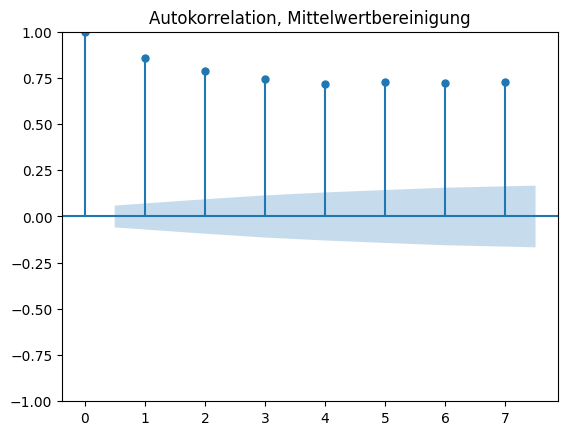

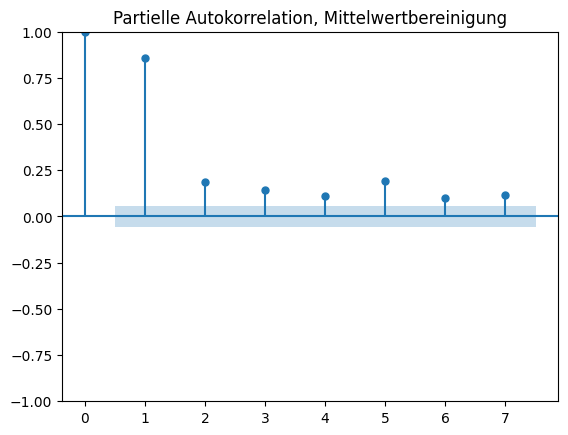

In [13]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, Mittelwertbereinigung', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, Mittelwertbereinigung', lags=lags)
plt.show()

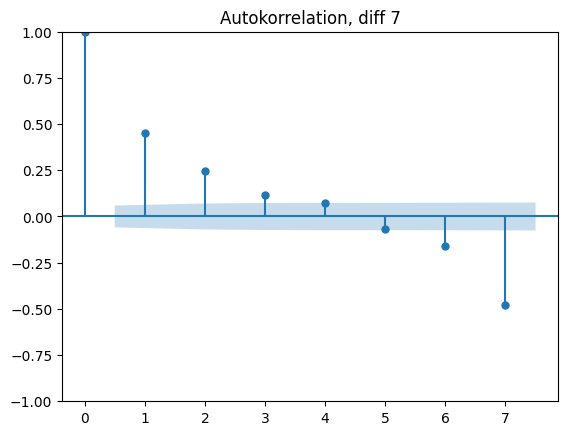

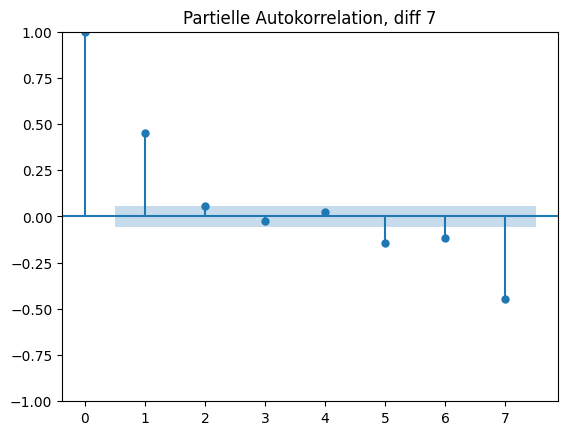

In [14]:
diffs = df['5.07 BN - Estermannufer'].diff(periods=lags).fillna(df['5.07 BN - Estermannufer']-df['day_mean'])
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags), lags=lags)
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags), lags=lags)
plt.show()

In [15]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

In [16]:
seasonal = 7
result1 = SARIMAX(df_train_seas['log'],order=(0,0,0),
 seasonal_order=(0,1,0,seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'],order=(0,1,0),
 seasonal_order=(0,1,0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'],order=(1,0,0),
 seasonal_order=(0,1,1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'],order=(1,0,0),
 seasonal_order=(0,1,2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'],order=(1,1,0),
 seasonal_order=(0,1,2, seasonal)).fit()

results = [result1, result2, result3, result4, result5]

In [17]:
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))

ARIMA (0,0,0)x(0,1,0,7) LL -1313.6759, AIC: 2629.3518
ARIMA (0,1,0)x(0,1,0,7) LL -1119.7119, AIC: 2241.4237
ARIMA (1,0,0)x(0,1,1,7) LL -800.8829, AIC: 1607.7658
ARIMA (1,0,0)x(0,1,2,7) LL -799.7288, AIC: 1607.4575
ARIMA (1,1,0)x(0,1,2,7) LL -822.3049, AIC: 1652.6098


In [18]:
for i in results:
    print(i.summary())

                                SARIMAX Results                                
Dep. Variable:                     log   No. Observations:                  876
Model:             SARIMAX(0, 1, 0, 7)   Log Likelihood               -1313.676
Date:                 Sun, 19 Jan 2025   AIC                           2629.352
Time:                         10:19:36   BIC                           2634.119
Sample:                     01-01-2021   HQIC                          2631.176
                          - 05-26-2023                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.2039      0.021     58.203      0.000       1.163       1.244
Ljung-Box (L1) (Q):                 402.46   Jarque-Bera (JB):              6716.58
Prob(Q):                              0